### Project: 
#### **Customer Segmentation using K-Means Clustering**

### Problem Statement

Businesses often struggle to understand different types of customers.
Without proper segmentation, marketing strategies become inefficient.

This project aims to group customers into meaningful segments based on their income and spending behavior using K-Means clustering.

### Objective

- To identify distinct customer groups
- To analyze customer purchasing behavior
- To help businesses target the right audience
- To improve decision-making using data

### STEP 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### STEP 2: Load Dataset

In [2]:
df = pd.read_csv("Realistic_Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Female,38,48.88,53
1,2,Female,41,122.13,25
2,3,Male,18,54.29,40
3,4,Female,38,121.40,19
4,5,Male,27,52.97,28


### STEP 3: Data Understanding

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              2000 non-null   int64  
 1   Gender                  2000 non-null   str    
 2   Age                     2000 non-null   int64  
 3   Annual Income (k$)      2000 non-null   float64
 4   Spending Score (1-100)  2000 non-null   int64  
dtypes: float64(1), int64(3), str(1)
memory usage: 78.3 KB


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

- Dataset is clean with no missing values and appropriate data types.


### STEP 4 : EDA

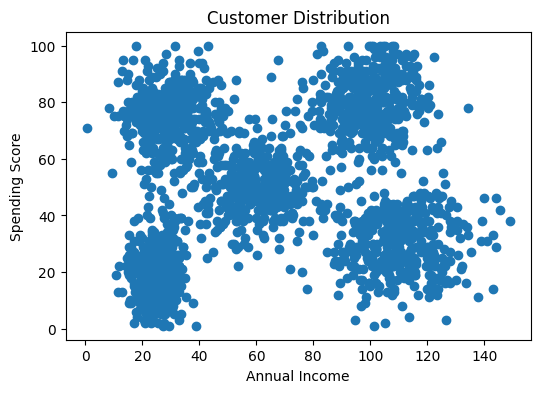

In [4]:
plt.figure(figsize=(6,4))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Distribution")
plt.show()

### STEP 5 : Feature Selection

- Selecting relevant features for clustering.

In [5]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

### STEP 6 : Feature Scaling

- Scaling ensures all features contribute equally to distance calculation.

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### STEP 7 : Elbow Method

- Used to determine the optimal number of clusters (K).

In [7]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

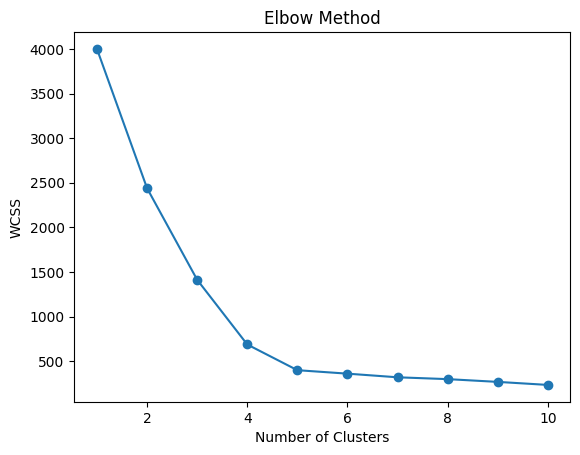

In [8]:
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

- The optimal K is selected at the "elbow point" where WCSS decreases slowly.

### STEP 8 : Apply K-Means

In [9]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

### STEP 9 : Visualization of Clusters

- Visualizing clusters to interpret customer segments.

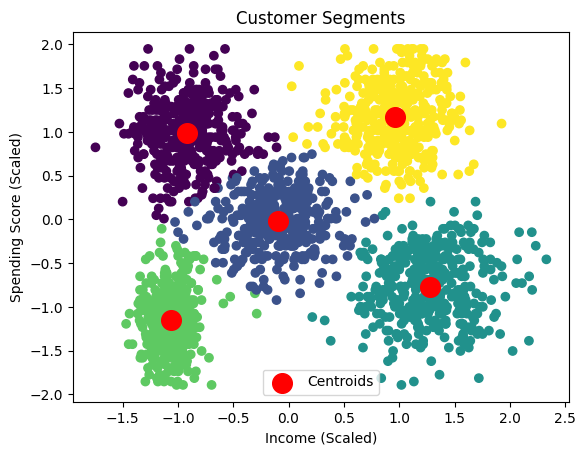

In [10]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_kmeans, cmap='viridis')

plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=200, c='red', label='Centroids')

plt.title("Customer Segments")
plt.xlabel("Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.legend()
plt.show()

### Insights from Customer Segmentation

- The K-Means algorithm successfully divided customers into 5 distinct clusters, clearly showing different spending behaviors based on income levels.

#### **Cluster 1: Low Income – High Spending**

(Left top cluster)

Characteristics:

Low income
High spending score

Insight:

These customers tend to spend a large portion of their income. They may be impulsive buyers or attracted by offers and discounts.

Business Strategy:

Provide discounts, coupons, and deals
Target with promotional campaigns

#### **Cluster 2: High Income – High Spending**

(Right top cluster)

Characteristics:

High income
High spending

Insight:

These are premium customers and the most valuable segment for the business.

Business Strategy:

Offer premium services
Loyalty programs
Exclusive memberships

#### **Cluster 3: Medium Income – Medium Spending**

(Center cluster)

Characteristics:

Average income
Average spending

Insight:

These are regular customers who provide stable revenue.

Business Strategy:

Maintain engagement
Offer personalized recommendations

#### **Cluster 4: Low Income – Low Spending**

(Bottom left cluster)

Characteristics:

Low income
Low spending

Insight:

These customers contribute less to revenue and are low-priority customers.

Business Strategy:

Minimal marketing investment
Focus only on basic engagement

#### **Cluster 5: High Income – Low Spending**

(Bottom right cluster)

Characteristics:

High income
Low spending

Insight:

These are potential customers who have the capacity to spend more but currently do not.

Business Strategy:

Target with personalized marketing
Offer premium product recommendations
Convert them into high spenders

### Conclusion

The K-Means clustering algorithm effectively segmented customers into meaningful groups based on their income and spending behavior.

The model identified premium, regular, low-value, and potential customers, allowing businesses to design targeted marketing strategies.

This segmentation can help improve customer engagement, increase sales, and optimize resource allocation.